# Por que os clientes cancelaram: leitura para Produto

**Pergunta de negócio:** o que levou cada cliente a cancelar de fato, o que faltou no produto e para onde ele foi, com myFarm e AgriManager separados.

**Quem lê:** equipe de produto.

**Fontes:**
- `relatorio-churn-2026-09-23.xlsx`: formulários de churn preenchidos pelo CS (motivo marcado, sistema de destino e histórico em texto).
- `Churn Tratado - Julio.xlsx`, aba Consolidado: cancelamentos confirmados de janeiro a junho, com motivo em texto livre.
- `leitura-casos-churn.csv` e `leitura-lacunas-churn.csv`: a leitura de cada histórico (motivo apurado, destino, lacunas de produto), feita à mão a partir das duas fontes acima e das reuniões de 17/09.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
COR_PRIMARIA   = "#0072B2"   # série principal
COR_SECUNDARIA = "#94A3B8"   # apoio / elementos neutros
COR_DESTAQUE   = "#E69F00"   # realçar o ponto-chave
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## Os formulários foram lidos corretamente?
Uma linha por pedido de cancelamento registrado pelo CS. Conferir tamanho, tipos e rótulos antes de qualquer conta.

In [3]:
form = pd.read_excel("relatorio-churn-2026-09-23.xlsx", sheet_name="Churn", dtype={"Código SD": str})
form.shape

(28, 31)

In [4]:
form[["Data solicitação", "MMR", "NPS", "Data assinatura contrato"]].dtypes.to_frame("tipo")

,tipo
Data solicitação,str
MMR,float64
NPS,int64
Data assinatura contrato,str


In [5]:
form[["Data solicitação", "Cliente", "UF", "MMR", "Tipo cancelamento", "Produtos cancelados", "Motivo churn cliente", "Sistema migração"]].head()

,Data solicitação,Cliente,UF,MMR,Tipo cancelamento,Produtos cancelados,Motivo churn cliente,Sistema migração
0,22/08/2026,MARCO ANTONIO ZUFFELLATO,GO,"1,200.83",Total,MYFARM,Falta de Funcionalidades Essenciais,NÃO CONFIRMADO
1,23/07/2026,JERLUCIO FERNANDES DE OLIVEIRA,GO,590.20,Total,MYFARM,Outro,EXCEL
2,08/07/2026,JOSE ARNALDO DE CASTRO NETTO IE 11511041-0,GO,296.67,Total,MYFARM,Outro,NÃO INFORMADO
3,07/07/2026,FRAVALE AGROPECUARIA LTDA,MG,705.61,Total,MYFARM,Dificuldade de Uso,NENHUM
4,17/06/2026,DIONATAN DONATO,RS,438.98,Total,MYFARM,Diminuição de custos,PLANILHAS


**Resultado:** leitura limpa. 28 formulários, MRR e NPS numéricos, acentos legíveis. As datas vieram como texto e serão convertidas.

## Que tipo de cancelamento está nos formulários?
Antes de somar, separar o que é cancelamento de sistema do que é serviço ou cancelamento parcial.

In [6]:
form["Tipo cancelamento"].value_counts().to_frame()

,count
Tipo cancelamento,
Total,26
Parcial,2


In [7]:
form["Produtos cancelados"].value_counts().to_frame()

,count
Produtos cancelados,
MYFARM,18
"SIAGRI AGRIMANAGER, AGM",4
SIAGRI AGRIMANAGER,2
"SIAGRI AGRIMANAGER, ALIARE CLOUD",1
SIAGRI AGRIMANAGER E ALIARE CLOUD,1
MY FARM ERP,1
BPO FINANCEIRO,1


**Resultado:** o mesmo produto aparece com grafias diferentes ("MYFARM" e "MY FARM ERP"; AgriManager com e sem Aliare Cloud). Um formulário é do serviço de BPO, com o cliente mantendo o myFarm: não é cancelamento de sistema e sai da leitura de produto. Os 2 parciais ficam, marcados.

In [8]:
def linha_produto(p):
    p = p.upper()
    if "BPO" in p:
        return "Serviço BPO"
    if "FARM" in p:
        return "myFarm"
    return "AgriManager"

form["linha"] = form["Produtos cancelados"].map(linha_produto)
form["data_pedido"] = pd.to_datetime(form["Data solicitação"], dayfirst=True)
form["data_contrato"] = pd.to_datetime(form["Data assinatura contrato"], dayfirst=True)
form[["Produtos cancelados", "linha", "Data solicitação", "data_pedido"]].drop_duplicates("Produtos cancelados")

,Produtos cancelados,linha,Data solicitação,data_pedido
0,MYFARM,myFarm,22/08/2026,2026-08-22
6,SIAGRI AGRIMANAGER,AgriManager,10/06/2026,2026-06-10
10,"SIAGRI AGRIMANAGER, AGM",AgriManager,28/05/2026,2026-05-28
13,"SIAGRI AGRIMANAGER, ALIARE CLOUD",AgriManager,25/05/2026,2026-05-25
14,SIAGRI AGRIMANAGER E ALIARE CLOUD,AgriManager,23/05/2026,2026-05-23
15,MY FARM ERP,myFarm,22/05/2026,2026-05-22
20,BPO FINANCEIRO,Serviço BPO,14/05/2026,2026-05-14


## Quantos cancelamentos e quanto MRR em cada produto?

In [9]:
form.groupby("linha").agg(casos=("Cliente", "size"), mrr=("MMR", "sum"),
                          primeiro_pedido=("data_pedido", "min"), ultimo_pedido=("data_pedido", "max"))

,casos,mrr,primeiro_pedido,ultimo_pedido
linha,,,,
AgriManager,8,"32,320.82",2026-03-09,2026-06-10
Serviço BPO,1,"1,355.74",2026-05-14,2026-05-14
myFarm,19,"18,607.89",2026-01-27,2026-08-22


**Resultado:** o AgriManager tem menos da metade dos formulários do myFarm e quase o dobro do MRR: são poucas contas grandes contra muitas pequenas, o mesmo desenho do relatório de janeiro a junho. Os formulários vão de janeiro a agosto, mas os de AgriManager param em junho.

## Os formulários cobrem os cancelamentos de janeiro a junho?
O relatório de janeiro a junho contou 39 eventos de churn (coluna "Considera no Churn?" = Sim). Cruzar pelo código do cliente para saber quais têm formulário.

In [10]:
cons = pd.read_excel("Churn Tratado - Julio.xlsx", sheet_name="Consolidado", header=3)
cons = cons[cons["Considera no Churn?"].eq("Sim")].copy()
cons["chave"] = cons["Cód. Cliente"].map(lambda v: "PREDIGER" if pd.isna(v) else str(int(v)))
cons["Produto"].value_counts().to_frame()

,count
Produto,
My Farm ERP,21
Agrimanager ERP,11
Aliare Cloud - PR,3
Vistra BI - PR,3
Agrimanager Algodoeira,1


In [11]:
familia = {"Agrimanager ERP": "AgriManager", "Agrimanager Algodoeira": "AgriManager",
           "Aliare Cloud - PR": "AgriManager", "My Farm ERP": "myFarm"}
cons["linha"] = cons["Produto"].map(familia)
cons_cli = (cons.dropna(subset=["linha"])
                .groupby(["chave", "linha"], as_index=False)
                .agg(cliente_cons=("Cliente", "first"), mrr_cons=("Perda (R$ positivo)", "sum"),
                     competencia=("Competência(s)", "first"), motivo_cons=("Motivo do Cancelamento (categoria)", "first")))
cons_cli["tem_formulario"] = cons_cli["chave"].isin(form["Código SD"])
cons_cli.groupby(["linha", "tem_formulario"]).agg(clientes=("chave", "size"), mrr=("mrr_cons", "sum"))

clientes       mrr
linha       tem_formulario                    
AgriManager False                  9 51,832.34
            True                   4 14,266.71
myFarm      False                 13 11,859.42
            True                   8  7,389.85

**Resultado:** dos 34 clientes de myFarm e AgriManager que saíram de janeiro a junho (R$ 85.348, o total de 17/09 sem o Vistra BI), só 12 têm formulário. No AgriManager o buraco pesa mais: 78% do valor perdido está em clientes sem formulário, puxado por Serios e Franciosi. Para esses, o motivo vem do texto livre do consolidado e o destino das reuniões de 17/09. [Certo]

## Como fica a base única de casos?
Formulários de sistema (sem o BPO) mais os cancelamentos de janeiro a junho sem formulário. O MRR vem do consolidado quando o cliente está nele (valor faturado que saiu), e do formulário quando ainda não está.

In [12]:
leit = pd.read_csv("leitura-casos-churn.csv", sep=";", dtype={"chave": str})
form_sis = form[form["linha"].ne("Serviço BPO")]
print("formulários sem leitura:", sorted(set(form_sis["Código SD"]) - set(leit["chave"])))
print("consolidado sem leitura:", sorted(set(cons_cli["chave"]) - set(leit["chave"])))
print("leitura sem fonte:", sorted(set(leit["chave"]) - set(form_sis["Código SD"]) - set(cons_cli["chave"])))
leit.shape

formulários sem leitura: []
consolidado sem leitura: []
leitura sem fonte: []


(49, 13)

In [13]:
base = (leit.merge(form_sis[["Código SD", "MMR", "data_pedido", "data_contrato", "Motivo churn cliente",
                             "Motivo churn cliente outro", "Sistema migração", "NPS", "Tipo cancelamento"]],
                   left_on="chave", right_on="Código SD", how="left")
            .merge(cons_cli[["chave", "mrr_cons", "competencia", "motivo_cons"]], on="chave", how="left"))
base["mrr"] = base["mrr_cons"].fillna(base["MMR"])
meses = {"jan": 1, "fev": 2, "mar": 3, "abr": 4, "mai": 5, "jun": 6}
comp = base["competencia"].str[:3].map(meses)
base["data"] = base["data_pedido"].fillna(pd.to_datetime(dict(year=2026, month=comp, day=1), errors="coerce"))
base[["cliente", "linha", "fonte", "MMR", "mrr_cons", "mrr", "data"]].sample(6, random_state=1)

,cliente,linha,fonte,MMR,mrr_cons,mrr,data
27,Serios Agropecuária,AgriManager,Registro jan a jun,NaN,"16,573.14","16,573.14",2026-02-01
34,Capivary Agropastoril,AgriManager,Registro jan a jun,NaN,"1,657.47","1,657.47",2026-01-01
39,Andre Luiz Coelho Guilherme,myFarm,Registro jan a jun,NaN,"1,073.29","1,073.29",2026-05-01
48,Leinner Lima Borges,myFarm,Registro jan a jun,NaN,302.91,302.91,2026-02-01
2,José Arnaldo de Castro Netto,myFarm,Formulário,296.67,NaN,296.67,2026-07-08
3,Fravale Agropecuária,myFarm,Formulário,705.61,NaN,705.61,2026-07-07


In [14]:
base.groupby(["linha", "fonte"]).agg(casos=("chave", "size"), mrr=("mrr", "sum"))

casos       mrr
linha       fonte                              
AgriManager Formulário              8 33,971.18
            Registro jan a jun      9 51,832.34
myFarm      Formulário             19 18,607.89
            Registro jan a jun     13 11,859.42

**Resultado:** 49 casos, sem sobra de nenhum lado: 32 de myFarm (R$ 30.467) e 17 de AgriManager (R$ 85.804). A diferença de R$ 1.650 no AgriManager com formulário é a Aliare Cloud do Bruno Sanches, que o formulário não soma e o consolidado sim.

## O motivo marcado no formulário bate com o que o histórico conta?
A regra da leitura: vale o motivo que o cliente declarou; quando o histórico mostra outra causa concreta, vale o histórico. Aqui se mede quantas vezes isso aconteceu.

In [15]:
DE_PARA = {
    "Falta de Funcionalidades Essenciais": "Faltou funcionalidade",
    "Falta de Personalização Solicitado pelo Cliente": "Faltou funcionalidade",
    "Dificuldade de Uso": "Sistema pesado para a equipe",
    "Erros Recorrentes / Instabilidade": "Erros e instabilidade",
    "Suporte Ineficiente ou Demorado": "Suporte lento e entrega sem prazo",
    "Diminuição de custos": "Usava só fiscal e financeiro",
    "Encerramento das Atividades da empresa": "Mudança no negócio do cliente",
}
f = base[base["fonte"].eq("Formulário")].copy()
f["motivo_marcado"] = f["Motivo churn cliente"].map(DE_PARA).fillna("Outro (texto livre)")
f["bate"] = f["motivo_marcado"].eq(f["motivo_apurado"])
f.groupby(f["motivo_marcado"].eq("Outro (texto livre)").map({True: "marcou Outro", False: "marcou categoria"}))["bate"].agg(["size", "sum"])

,size,sum
motivo_marcado,,
marcou Outro,6,0
marcou categoria,21,13


In [16]:
f.loc[~f["bate"] & f["motivo_marcado"].ne("Outro (texto livre)"), ["cliente", "linha", "Motivo churn cliente", "motivo_apurado"]]

,cliente,linha,Motivo churn cliente,motivo_apurado
4,Dionatan Donato,myFarm,Diminuição de custos,Mudança no negócio do cliente
8,Fabiano Bergoli Zamberlan,myFarm,Erros Recorrentes / Instabilidade,Sistema pesado para a equipe
14,Lucival Portilho Arantes,AgriManager,Falta de Funcionalidades Essenciais,Venda ou implantação desalinhada
15,Evandro Vilela Barros,myFarm,Falta de Funcionalidades Essenciais,Usava só fiscal e financeiro
16,Edgar Gomes Filho,myFarm,Dificuldade de Uso,Erros e instabilidade
22,Agropecuária Estrela da Manhã,AgriManager,Dificuldade de Uso,Mudança no negócio do cliente
23,Augusto Cesar Andrade Maia,myFarm,Falta de Funcionalidades Essenciais,Erros e instabilidade
24,Claudio Augusto Diniz,AgriManager,Dificuldade de Uso,Usava só fiscal e financeiro


**Resultado:** em 8 dos 21 formulários com categoria marcada, o histórico aponta outra causa principal; nos 6 marcados como "Outro" o texto livre foi lido um a um. Três marcados como falta de funcionalidade eram, pelo histórico, instabilidade, projeto que não entrou em produção e uso restrito ao financeiro. Ler só o campo de motivo levaria o produto a olhar para o lugar errado em um de cada três casos. [Provável: a leitura do histórico é interpretação, com n = 21]

## Por que saíram, em cada produto?
Motivo apurado em 10 categorias, agrupadas em Produto, Venda e suporte, Cliente e Sem registro. Contagem de casos e MRR lado a lado, porque no AgriManager poucos clientes concentram o valor.

In [17]:
GRUPO = {
    "Faltou funcionalidade": "Produto",
    "Erros e instabilidade": "Produto",
    "Sistema pesado para a equipe": "Produto",
    "Venda ou implantação desalinhada": "Venda e suporte",
    "Suporte lento e entrega sem prazo": "Venda e suporte",
    "Usava só fiscal e financeiro": "Cliente",
    "Não usou o sistema": "Cliente",
    "Mudança no negócio do cliente": "Cliente",
    "Dificuldade financeira do cliente": "Cliente",
    "Motivo não apurado": "Sem registro",
}
base["grupo"] = base["motivo_apurado"].map(GRUPO)
base["grupo"].isna().sum()

np.int64(0)

In [18]:
motivos = (base.groupby(["linha", "grupo", "motivo_apurado"])
               .agg(casos=("chave", "size"), mrr=("mrr", "sum"))
               .reset_index())
motivos["pct_casos"] = motivos["casos"] / motivos.groupby("linha")["casos"].transform("sum")
motivos["pct_mrr"] = motivos["mrr"] / motivos.groupby("linha")["mrr"].transform("sum")
motivos.sort_values(["linha", "casos", "mrr"], ascending=[True, False, False])

,linha,grupo,motivo_apurado,casos,mrr,pct_casos,pct_mrr
4,AgriManager,Sem registro,Motivo não apurado,7,"47,385.25",0.41,0.55
2,AgriManager,Produto,Faltou funcionalidade,3,"12,878.16",0.18,0.15
0,AgriManager,Cliente,Mudança no negócio do cliente,2,"9,846.03",0.12,0.11
1,AgriManager,Cliente,Usava só fiscal e financeiro,2,"5,065.87",0.12,0.06
6,AgriManager,Venda e suporte,Venda ou implantação desalinhada,1,"5,896.12",0.06,0.07
5,AgriManager,Venda e suporte,Suporte lento e entrega sem prazo,1,"2,581.48",0.06,0.03
3,AgriManager,Produto,Sistema pesado para a equipe,1,"2,150.61",0.06,0.03
9,myFarm,Cliente,Não usou o sistema,7,"6,270.52",0.22,0.21
12,myFarm,Produto,Faltou funcionalidade,7,"5,876.37",0.22,0.19
11,myFarm,Produto,Erros e instabilidade,5,"8,091.76",0.16,0.27


In [19]:
grupos = base.groupby(["linha", "grupo"]).agg(casos=("chave", "size"), mrr=("mrr", "sum"))
grupos["pct_casos"] = grupos["casos"] / grupos.groupby("linha")["casos"].transform("sum")
grupos["pct_mrr"] = grupos["mrr"] / grupos.groupby("linha")["mrr"].transform("sum")
grupos

casos       mrr  pct_casos  pct_mrr
linha       grupo                                               
AgriManager Cliente              4 14,911.90       0.24     0.17
            Produto              4 15,028.77       0.24     0.18
            Sem registro         7 47,385.25       0.41     0.55
            Venda e suporte      2  8,477.60       0.12     0.10
myFarm      Cliente             14 11,485.81       0.44     0.38
            Produto             15 16,575.09       0.47     0.54
            Sem registro         2  1,785.15       0.06     0.06
            Venda e suporte      1    621.26       0.03     0.02

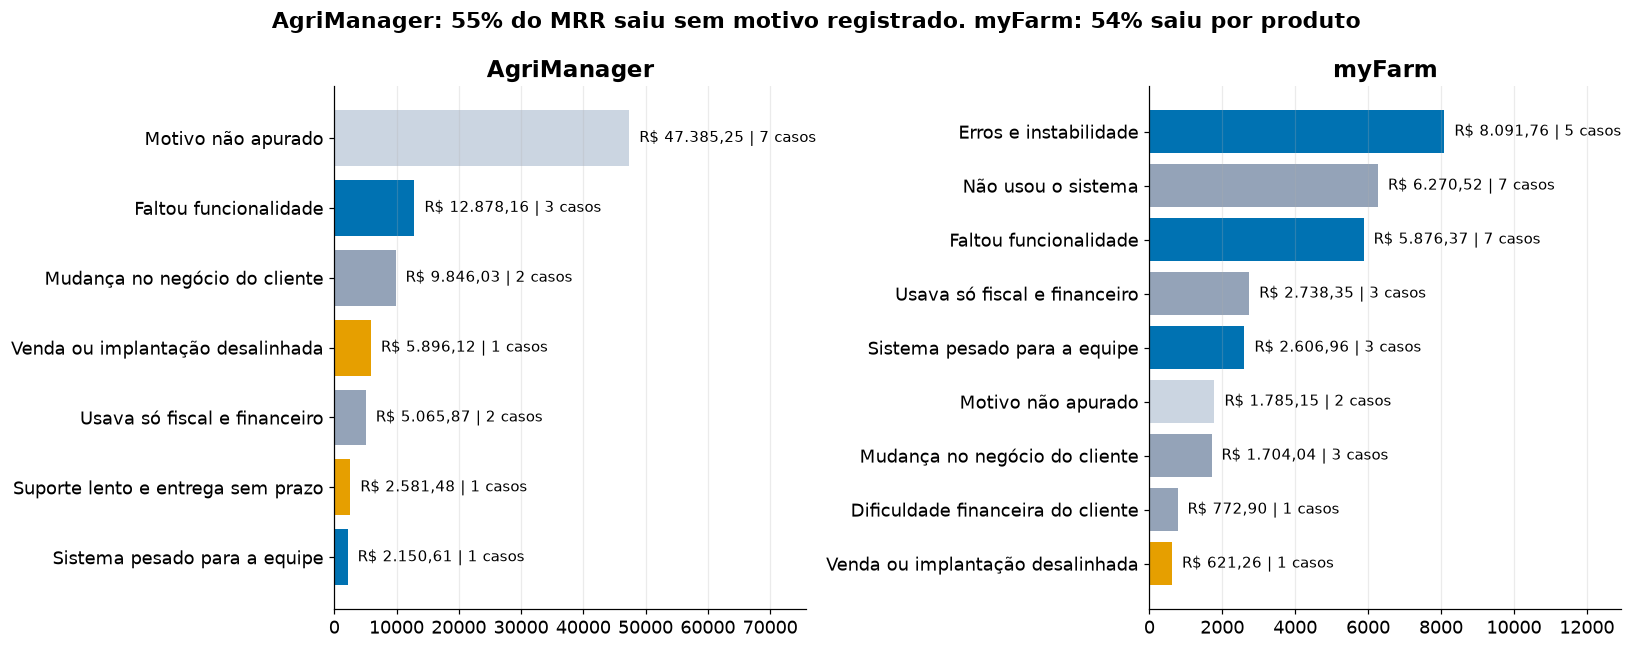

In [20]:
CORES_GRUPO = {"Produto": COR_PRIMARIA, "Venda e suporte": COR_DESTAQUE,
               "Cliente": COR_SECUNDARIA, "Sem registro": "#CBD5E1"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (linha, d) in zip(axes, motivos.groupby("linha")):
    d = d.sort_values("mrr")
    ax.barh(d["motivo_apurado"], d["mrr"], color=d["grupo"].map(CORES_GRUPO))
    for y, (v, n) in enumerate(zip(d["mrr"], d["casos"])):
        ax.text(v, y, f"  {reais(v)} | {n} casos", va="center", fontsize=10)
    ax.set_xlim(0, d["mrr"].max() * 1.6)
    ax.set_title(linha)
    ax.grid(axis="y", visible=False)
fig.suptitle("AgriManager: 55% do MRR saiu sem motivo registrado. myFarm: 54% saiu por produto", fontweight="bold")
plt.tight_layout()

**Resultado:** são dois retratos diferentes.
- **myFarm:** quase metade das saídas é por causa do próprio produto (faltou funcionalidade, erros, sistema pesado para a equipe), e erros e instabilidade é o motivo que mais tira MRR. O outro bloco grande é de clientes que não chegaram a usar o sistema, que é agenda de implantação e CS.
- **AgriManager:** onde está o dinheiro, falta o porquê. Sete clientes, 55% do MRR, saíram sem motivo registrado, e os sete foram para outro ERP. Serios e Franciosi respondem por dois terços desse valor. Onde há motivo, ele é espalhado: funcionalidade, venda do negócio, uso só fiscal, implantação, suporte.

Composição, não risco: não há aqui a base ativa por produto para calcular taxa, então o que se lê é o peso de cada motivo entre quem saiu. [Certo quanto às contas, Provável quanto à classificação]

## Para onde foram?
Destino agrupado por tipo, com o nome do sistema quando se sabe. Destino de reunião (17/09) está marcado na coluna de fonte.

In [21]:
destinos = (base.groupby(["linha", "destino_tipo"])
                .agg(casos=("chave", "size"), mrr=("mrr", "sum"))
                .sort_values(["casos", "mrr"], ascending=False))
destinos

casos       mrr
linha       destino_tipo                                         
myFarm      Não informado                            19 19,636.85
AgriManager ERP concorrente                          13 71,253.37
myFarm      ERP concorrente                           3  3,399.99
            Contabilidade ou emissor fiscal           3  2,543.96
            Planilhas                                 3  2,099.18
AgriManager Negócio vendido, parado ou encerrado      2  9,846.03
myFarm      Negócio vendido, parado ou encerrado      2  1,265.06
AgriManager Continua na Aliare                        1  3,046.65
            Contabilidade ou emissor fiscal           1  1,657.47
myFarm      Solução própria                           1  1,202.27
            Software de pecuária                      1    320.00

In [22]:
nomeados = base[base["destino_tipo"].eq("ERP concorrente")]
nomeados.groupby(["linha", "destino", "fonte_destino"]).agg(casos=("chave", "size"), mrr=("mrr", "sum"), clientes=("cliente", ", ".join))

casos       mrr  \
linha       destino                  fonte_destino                         
AgriManager Aegro                    Formulário              1  2,150.61   
            Agro1                    Formulário              1  2,581.48   
            Conecter (a confirmar)   Reunião 17/09           1 15,628.64   
            Outro ERP, não informado Formulário              1  7,913.82   
                                     Registro jan a jun      4  7,269.65   
            Outro ERP, não nomeado   Reunião 17/09           1  5,661.05   
            SAP                      Reunião 17/09           2 20,743.60   
            Siacon                   Formulário              1  5,896.12   
            Tron                     Histórico               1  3,408.40   
myFarm      Gerente Rural            Formulário              1    870.18   
            Katrid                   Formulário              1  1,327.99   
            Outro ERP, não informado Registro jan a jun      1  1,201.82   

                                                                                                                      clientes  
linha       destino                  fonte_destino                                                                              
AgriManager Aegro                    Formulário                                               Octaviano Raymundo Camargo Silva  
            Agro1                    Formulário                                                                Gemiro Carafini  
            Conecter (a confirmar)   Reunião 17/09                                                          Clodoveu Franciosi  
            Outro ERP, não informado Formulário                                                                   Celso Manica  
                                     Registro jan a jun  Zorzetto Assessoria e Consultoria Agronômica, Valquiria Marcelino ...  
            Outro ERP, não nomeado   Reunião 17/09                                                          Bruno Sanches Toro  
            SAP                      Reunião 17/09                                 Serios Agropecuária, 3SB Produtos Agrícolas  
            Siacon                   Formulário                                                       Lucival Portilho Arantes  
            Tron                     Histórico                                                           Claudio Augusto Diniz  
myFarm      Gerente Rural            Formulário                                                            Cleonesio Luiz Marx  
            Katrid                   Formulário                                                           Mario Pinto da Silva  
            Outro ERP, não informado Registro jan a jun                                                           Flavio Faedo

**Resultado:** os dois produtos perdem para lugares diferentes.
- **AgriManager** perde para ERP: 13 dos 17 clientes, 83% do MRR. Com nome: SAP (Serios e 3SB, pelas reuniões), Conecter (Franciosi, nome a confirmar), Siacon, Tron, Agro1 e Aegro. Seis foram para ERP sem nome registrado, entre eles Celso Manica, o maior MRR dos formulários.
- **myFarm** perde, na maior parte, sem saber para onde: 19 dos 32 não informaram. Entre os que informaram, sair do ERP (planilha, app da contabilidade, emissor de nota, aplicativo próprio) aparece mais do que trocar por outro ERP (7 contra 3). O concorrente do myFarm é tanto o ERP ao lado quanto não ter ERP. [Certo quanto aos informados; o "não informado" pode esconder outro padrão]

## O que faltou no produto?
Cada menção de lacuna é atribuída ao produto que não tinha o recurso. Dois clientes de AgriManager (Octaviano e Lucival) aparecem no myFarm porque a falta de recurso contábil do myFarm impediu a troca de produto.

In [23]:
lac = pd.read_csv("leitura-lacunas-churn.csv", sep=";", dtype={"chave": str})
lac = lac.merge(base[["chave", "linha", "mrr"]], on="chave", how="left")
print("lacunas sem caso:", lac["linha"].isna().sum())
lac.shape

lacunas sem caso: 0


(39, 8)

In [24]:
por_tema = (lac.drop_duplicates(["produto_da_lacuna", "tema", "chave"])
               .assign(outra_linha=lambda d: d["linha"].ne(d["produto_da_lacuna"]))
               .groupby(["produto_da_lacuna", "tema"])
               .agg(clientes=("chave", "size"), mrr=("mrr", "sum"), de_outra_linha=("outra_linha", "sum"),
                    nomes=("cliente", ", ".join))
               .sort_values(["clientes", "mrr"], ascending=False))
por_tema

clientes       mrr  \
produto_da_lacuna tema                                                  
myFarm            Estabilidade e desempenho               8 10,770.14   
                  Relatórios gerenciais                   4  5,091.01   
                  Simplicidade para equipe enxuta         4  3,617.90   
AgriManager       Plataforma e acesso                     3  9,036.53   
myFarm            Contabilidade e multiempresa            3  8,654.10   
                  Pecuária                                3  2,127.99   
AgriManager       Integração e automação                  2  9,831.51   
                  Simplicidade para equipe enxuta         2  5,559.01   
                  Financeiro e conciliação                1  5,661.05   
                  Relatórios gerenciais                   1  2,150.61   
myFarm            Implantação e carga de dados            1  1,950.00   
                  Automação de notas de entrada           1  1,327.99   
                  Fiscal e livro caixa                    1  1,200.83   
                  Armazenagem de terceiros                1  1,070.00   
                  Integração com a contabilidade          1    705.61   

                                                   de_outra_linha  \
produto_da_lacuna tema                                              
myFarm            Estabilidade e desempenho                     0   
                  Relatórios gerenciais                         0   
                  Simplicidade para equipe enxuta               0   
AgriManager       Plataforma e acesso                           0   
myFarm            Contabilidade e multiempresa                  2   
                  Pecuária                                      0   
AgriManager       Integração e automação                        0   
                  Simplicidade para equipe enxuta               0   
                  Financeiro e conciliação                      0   
                  Relatórios gerenciais                         0   
myFarm            Implantação e carga de dados                  0   
                  Automação de notas de entrada                 0   
                  Fiscal e livro caixa                          0   
                  Armazenagem de terceiros                      0   
                  Integração com a contabilidade                0   

                                                                                                                   nomes  
produto_da_lacuna tema                                                                                                    
myFarm            Estabilidade e desempenho        Marco Antonio Zuffellato, Agro Aliança, Edgar Gomes Filho, Paulo E...  
                  Relatórios gerenciais            Marco Antonio Zuffellato, Agro Aliança, Pedro Alceu Bach, Cleonesi...  
                  Simplicidade para equipe enxuta  Fravale Agropecuária, Paulo Ricardo Santin, Fabiano Bergoli Zamber...  
AgriManager       Plataforma e acesso                           Natalino Bigolin, Claudio Augusto Diniz, Gemiro Carafini  
myFarm            Contabilidade e multiempresa     Octaviano Raymundo Camargo Silva, Lucival Portilho Arantes, Paulo ...  
                  Pecuária                         Mario Pinto da Silva, Eliana Gasparini Testa, Geraldo Augusto Mart...  
AgriManager       Integração e automação                                      Bruno Sanches Toro, 3SB Produtos Agrícolas  
                  Simplicidade para equipe enxuta                Octaviano Raymundo Camargo Silva, Claudio Augusto Diniz  
                  Financeiro e conciliação                                                            Bruno Sanches Toro  
                  Relatórios gerenciais                                                 Octaviano Raymundo Camargo Silva  
myFarm            Implantação e carga de dados                                                              Agro Aliança  
                  Automação de notas

**Resultado:** só seis temas têm 3 ou mais clientes; o resto é caso único e deve ser lido como pedido concreto, não como padrão.
- **myFarm:** estabilidade e desempenho lidera (8 clientes, R$ 10.770), seguida de relatórios gerenciais (custo por safra, talhão e máquinas; estoque em data base; armazenagem), simplicidade para equipe enxuta, contabilidade e multiempresa (DRE por competência, balancete, vários CNPJs) e pecuária (confinamento, leilão, leite).
- **AgriManager:** plataforma (várias telas ao mesmo tempo, operar 100% online, acesso ao banco na nuvem) e integração e automação (lançamentos automáticos, integração com outros sistemas).
- **Sistema pesado para equipe enxuta aparece nos dois produtos**: 4 clientes de myFarm e 2 de AgriManager. O myFarm, que é a opção simples da casa, também é visto como pesado por fazenda com uma ou duas pessoas no administrativo. [Certo quanto às menções; n pequeno por tema]

## A troca entre AgriManager e myFarm segurou algum cliente?
Nos históricos, a troca de produto aparece como tentativa de retenção. Ver em quantos casos e por que não funcionou.

In [25]:
base.loc[base["troca_entre_produtos"].notna(), ["cliente", "linha", "mrr", "troca_entre_produtos", "motivo_apurado", "destino"]]

,cliente,linha,mrr,troca_entre_produtos,motivo_apurado,destino
6,Gemiro Carafini,AgriManager,"2,581.48",myFarm oferecido e recusado,Suporte lento e entrega sem prazo,Agro1
12,Octaviano Raymundo Camargo Silva,AgriManager,"2,150.61",myFarm apresentado e não atendeu,Sistema pesado para a equipe,Aegro
14,Lucival Portilho Arantes,AgriManager,"5,896.12",Saiu do myFarm para o AGM em 2025,Venda ou implantação desalinhada,Siacon
18,Pedro Alceu Bach,myFarm,"1,070.00","AGM citado como alternativa, exige equipe maior",Faltou funcionalidade,Planilhas
22,Agropecuária Estrela da Manhã,AgriManager,"3,313.05",myFarm avaliado e recusado,Mudança no negócio do cliente,"Nenhum, fazendas sem operar"
24,Claudio Augusto Diniz,AgriManager,"3,408.40",myFarm oferecido por R$ 738 e recusado,Usava só fiscal e financeiro,Tron


## Quem saiu por venda desalinhada saiu cedo?
Meses entre a assinatura do contrato vigente e o pedido de cancelamento, só para formulários. A data é do contrato vigente: em renovações ela subestima o tempo de casa.

In [26]:
f = base[base["fonte"].eq("Formulário")].copy()
f["meses_de_contrato"] = ((f["data_pedido"] - f["data_contrato"]).dt.days / 30.4).round(1)
f.groupby("venda_desalinhada")["meses_de_contrato"].describe()[["count", "min", "50%", "max"]]

,count,min,50%,max
venda_desalinhada,,,,
Não,22.00,7.10,31.55,84.90
Sim,5.00,1.40,4.60,13.80


In [27]:
f.loc[f["meses_de_contrato"].lt(8), ["cliente", "linha", "meses_de_contrato", "motivo_apurado", "venda_desalinhada"]].sort_values("meses_de_contrato")

,cliente,linha,meses_de_contrato,motivo_apurado,venda_desalinhada
20,Mario Pinto da Silva,myFarm,1.40,Faltou funcionalidade,Sim
11,Agro Aliança,myFarm,2.70,Erros e instabilidade,Sim
18,Pedro Alceu Bach,myFarm,4.60,Faltou funcionalidade,Sim
14,Lucival Portilho Arantes,AgriManager,7.00,Venda ou implantação desalinhada,Sim
1,Jerlucio Fernandes de Oliveira,myFarm,7.10,Não usou o sistema,Não


**Resultado:** os 5 formulários em que a venda não bateu com o produto saíram com mediana de 4,6 meses de contrato (de 1,4 a 13,8), contra 31,6 meses dos demais. Os quatro cancelamentos mais rápidos são todos desse grupo: Mario (1,4), Agro Aliança (2,7), Pedro Bach (4,6) e Lucival (7,0). Jerlucio aparece com 7,1 porque a data é de renovação; ele é cliente desde 2023. Base pequena e data de contrato vigente, então é sinal, não medida. [Provável, n = 5]

## O que muda em relação ao relatório de janeiro a junho?
Para os 12 clientes que estão nos dois lugares, comparar a categoria usada em 17/09 com o motivo apurado agora e o destino que ficou conhecido.

In [28]:
comp = base[base["fonte"].eq("Formulário") & base["mrr_cons"].notna()]
comp[["cliente", "linha", "motivo_cons", "motivo_apurado", "destino"]]

,cliente,linha,motivo_cons,motivo_apurado,destino
5,Wagner Eduardo Baldin Pereira,myFarm,Encerramento de atividades,Mudança no negócio do cliente,"Nenhum, arrendou a área"
7,Paulo Ricardo Santin,myFarm,Baixa adoção / não uso,Sistema pesado para a equipe,Não informado
8,Fabiano Bergoli Zamberlan,myFarm,Falta de mão de obra / estrutura,Sistema pesado para a equipe,Não informado
12,Octaviano Raymundo Camargo Silva,AgriManager,Falta de mão de obra / estrutura,Sistema pesado para a equipe,Aegro
13,Natalino Bigolin,AgriManager,Gap funcional / limitação do produto,Faltou funcionalidade,"Servidor próprio, segue com o AGM"
15,Evandro Vilela Barros,myFarm,Troca de ERP,Usava só fiscal e financeiro,Sistema da contabilidade
17,Paulo Emílio Paludo,myFarm,Gap funcional / limitação do produto,Faltou funcionalidade,Não informado
18,Pedro Alceu Bach,myFarm,Recursos do produto,Faltou funcionalidade,Planilhas
20,Mario Pinto da Silva,myFarm,Gap funcional / limitação do produto,Faltou funcionalidade,Katrid
21,Bruno Sanches Toro,AgriManager,Gap funcional / limitação do produto,Faltou funcionalidade,"Outro ERP, não nomeado"


**Resultado:** a categoria muda de nome em quase todos (os vocabulários são diferentes), mas muda de sentido em 5 dos 12: Claudio Diniz (baixa adoção para uso só fiscal, foi para o Tron), Octaviano (falta de mão de obra para sistema pesado, foi para o Aegro), Evandro (troca de ERP para sistema da contabilidade), Paulo Santin e Fabiano (baixa adoção e falta de mão de obra para sistema pesado). Dois clientes de AgriManager lidos em 17/09 como adoção e mão de obra foram para concorrente: a perda para ERP no AgriManager é maior do que o relatório de janeiro a junho mostrava. [Certo quanto aos destinos, que vêm do formulário]

## Conclusão

**Base:** 49 cancelamentos de janeiro a agosto de 2026, 32 de myFarm (R$ 30.467 de MRR) e 17 de AgriManager, com Aliare Cloud e Algodoeira (R$ 85.804). 27 com formulário de churn e 22 só com o registro de janeiro a junho.

1. **myFarm perde por produto e por falta de uso.** 15 dos 32 saíram por produto (54% do MRR): erros e instabilidade, funcionalidade que faltou (contabilidade e multiempresa, pecuária, armazenagem de terceiros, relatórios de custo, livro caixa) e sistema pesado para equipe enxuta. Outros 7 não chegaram a usar o sistema.
2. **myFarm perde mais para "sem ERP" do que para concorrente.** 19 dos 32 não disseram para onde foram. Entre os que disseram, 7 foram para planilha, app da contabilidade, emissor de nota ou aplicativo próprio, e 3 para outro ERP (Gerente Rural, Katrid e um sem nome).
3. **AgriManager perde para ERP.** 13 dos 17, 83% do MRR: SAP (2), Conecter (a confirmar), Siacon, Tron, Agro1, Aegro e 6 sem nome. Em 7 deles, 55% do MRR, o motivo não foi registrado; Serios e Franciosi respondem por dois terços desse valor.
4. **As lacunas de AgriManager são de plataforma e automação:** várias telas ao mesmo tempo, operar 100% online, acesso ao banco na nuvem, lançamento automático e integração com outros sistemas, pagamento antecipado a fornecedor.
5. **A troca entre os dois produtos não segurou ninguém.** Tentada em 6 casos; 4 foram para outro ERP. O myFarm não cobre contábil, multiempresa e armazenagem; o AgriManager pede equipe que a fazenda não tem.
6. **Venda desalinhada sai cedo:** mediana de 4,6 meses de contrato, contra 31,6 dos demais.
7. **O campo de motivo do formulário não basta:** em 8 de 21, o histórico aponta outra causa.

## Dados para o relatório em HTML
Exporta os casos e as lacunas já lidos, na forma que a página usa.

In [29]:
import json

cols = ["chave", "cliente", "linha", "produto", "fonte", "mrr", "grupo", "motivo_apurado", "fatores", "destino",
        "destino_tipo", "fonte_destino", "venda_desalinhada", "troca_entre_produtos", "evidencia",
        "Motivo churn cliente", "Tipo cancelamento", "motivo_cons"]
casos = base.assign(mes=base["data"].dt.strftime("%m/%Y"))[cols + ["mes"]]
casos = casos.astype(object).where(casos.notna(), None)
lac_out = lac[["chave", "cliente", "produto_da_lacuna", "tema", "detalhe", "fonte", "linha", "mrr"]]
with open("dados-motivos-churn.json", "w", encoding="utf-8") as fh:
    json.dump({"casos": casos.to_dict("records"), "lacunas": lac_out.to_dict("records")}, fh, ensure_ascii=False, indent=1)
len(casos), len(lac_out)

(49, 39)